In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
original_df = pd.read_csv('4.3_dataset_clean_v2.csv')

In [39]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5592 entries, 0 to 5591
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   link              5592 non-null   object 
 1   address           5592 non-null   object 
 2   apartment_name    5592 non-null   object 
 3   sector            5592 non-null   object 
 4   price             5592 non-null   float64
 5   price_sqft        5592 non-null   float64
 6   super_area        5592 non-null   float64
 7   bedrooms          5592 non-null   int64  
 8   bathroom          5592 non-null   int64  
 9   balcony           5592 non-null   object 
 10  additional_rooms  3945 non-null   object 
 11  age_possession    5592 non-null   object 
 12  floor             5592 non-null   object 
 13  floor_num         5592 non-null   int64  
 14  total_floors      5592 non-null   int64  
 15  furnishing_type   5592 non-null   object 
 16  facing            5592 non-null   object 


In [40]:
df = original_df.drop(columns = ['link','address','additional_rooms','floor', 'num_parking','features'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5592 entries, 0 to 5591
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   apartment_name   5592 non-null   object 
 1   sector           5592 non-null   object 
 2   price            5592 non-null   float64
 3   price_sqft       5592 non-null   float64
 4   super_area       5592 non-null   float64
 5   bedrooms         5592 non-null   int64  
 6   bathroom         5592 non-null   int64  
 7   balcony          5592 non-null   object 
 8   age_possession   5592 non-null   object 
 9   floor_num        5592 non-null   int64  
 10  total_floors     5592 non-null   int64  
 11  furnishing_type  5592 non-null   object 
 12  facing           5592 non-null   object 
 13  servant_room     5592 non-null   int64  
 14  study_room       5592 non-null   int64  
 15  pooja_room       5592 non-null   int64  
 16  store_room       5592 non-null   int64  
 17  luxury_score  

In [41]:
df.head()

,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
0,bharat residency,jharsa,0.70,5477.3,1278.0000,2,2,2,1 to 5 year old,0,4,Semifurnished,na,0,0,0,1,21,medium,1
1,gls arawali homes,sohna,0.38,5569.0,682.3526,2,2,2,1 to 5 year old,6,13,Semifurnished,East,0,0,0,0,35,medium,2
2,chd avenue 71,sector 71,1.35,11268.8,1198.0000,2,2,2,10+ year old,1,14,Unfurnished,North,0,0,0,0,71,high,1
3,signature avenue,sector 82,3.40,10493.8,3240.0000,4,4,2,0 to 1 year old,4,4,Furnished,North-East,1,0,1,0,28,medium,2
4,signature global park,sohna,0.95,8920.2,1065.0000,2,2,2,0 to 1 year old,1,4,Semifurnished,na,0,0,0,0,18,low,1


In [42]:
df.drop(columns = ['apartment_name', 'price_sqft','luxury_score'], inplace = True)
df.head()

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,floor_num,total_floors,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking
0,jharsa,0.70,1278.0000,2,2,2,1 to 5 year old,0,4,Semifurnished,na,0,0,0,1,medium,1
1,sohna,0.38,682.3526,2,2,2,1 to 5 year old,6,13,Semifurnished,East,0,0,0,0,medium,2
2,sector 71,1.35,1198.0000,2,2,2,10+ year old,1,14,Unfurnished,North,0,0,0,0,high,1
3,sector 82,3.40,3240.0000,4,4,2,0 to 1 year old,4,4,Furnished,North-East,1,0,1,0,medium,2
4,sohna,0.95,1065.0000,2,2,2,0 to 1 year old,1,4,Semifurnished,na,0,0,0,0,low,1


In [43]:
df['total_floors'].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

0.10    10.0
0.20    14.0
0.30    14.0
0.40    17.0
0.50    19.0
0.60    21.0
0.70    24.0
0.80    27.0
0.90    33.0
0.95    36.9
0.99    47.0
Name: total_floors, dtype: float64

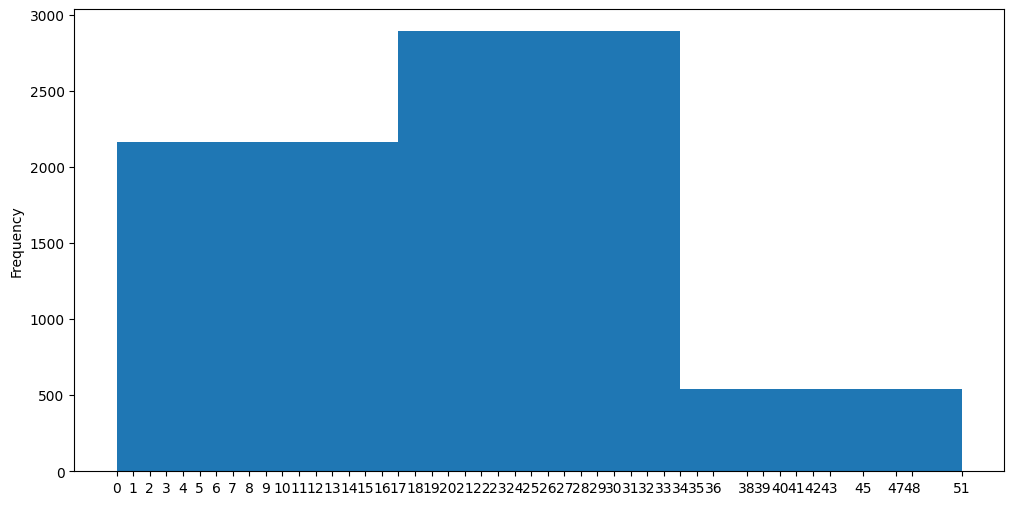

In [44]:
plt.figure(figsize = (12,6))
df['total_floors'].plot(kind= 'hist' , bins = 3)
plt.xticks(ticks = df['total_floors'].unique())
plt.show()

In [45]:
def categorise_floor(row):
    if row['floor_num'] < row['total_floors']*0.3:
        return('lower-floor')
    if row['floor_num'] < row['total_floors']*0.6:
        return('middle-floor') 
    else:
        return('high-floor')
df['floor'] = df.apply(categorise_floor,axis=1)

In [46]:
def categorise_total_floor(row):
    if row['total_floors'] < 5:
        return('low-rise')
    if row['total_floors'] < 24:
        return('mid-rise') 
    else:
        return('high-rise')
df['building_type'] = df.apply(categorise_total_floor,axis=1)

<Axes: ylabel='total_floors'>

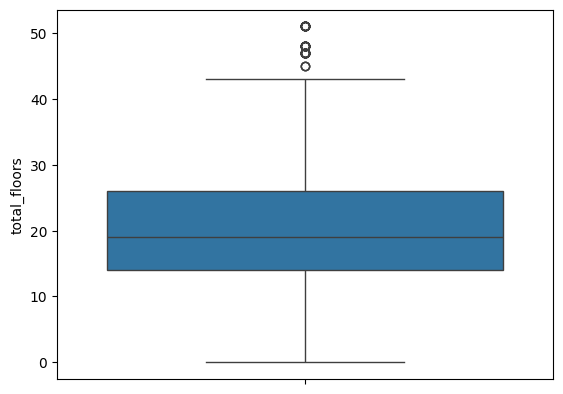

In [47]:
sns.boxplot(df['total_floors'])

In [48]:
df['total_floors'].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

0.10    10.0
0.20    14.0
0.30    14.0
0.40    17.0
0.50    19.0
0.60    21.0
0.70    24.0
0.80    27.0
0.90    33.0
0.95    36.9
0.99    47.0
Name: total_floors, dtype: float64

In [49]:
df.drop(columns=['floor_num','total_floors'],inplace=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5592 entries, 0 to 5591
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5592 non-null   object 
 1   price            5592 non-null   float64
 2   super_area       5592 non-null   float64
 3   bedrooms         5592 non-null   int64  
 4   bathroom         5592 non-null   int64  
 5   balcony          5592 non-null   object 
 6   age_possession   5592 non-null   object 
 7   furnishing_type  5592 non-null   object 
 8   facing           5592 non-null   object 
 9   servant_room     5592 non-null   int64  
 10  study_room       5592 non-null   int64  
 11  pooja_room       5592 non-null   int64  
 12  store_room       5592 non-null   int64  
 13  luxury_category  5592 non-null   object 
 14  parking          5592 non-null   int64  
 15  floor            5592 non-null   object 
 16  building_type    5592 non-null   object 
dtypes: float64(2),

## Feature Selection

In [51]:
df_non_feature_selected = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5592 entries, 0 to 5591
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5592 non-null   object 
 1   price            5592 non-null   float64
 2   super_area       5592 non-null   float64
 3   bedrooms         5592 non-null   int64  
 4   bathroom         5592 non-null   int64  
 5   balcony          5592 non-null   object 
 6   age_possession   5592 non-null   object 
 7   furnishing_type  5592 non-null   object 
 8   facing           5592 non-null   object 
 9   servant_room     5592 non-null   int64  
 10  study_room       5592 non-null   int64  
 11  pooja_room       5592 non-null   int64  
 12  store_room       5592 non-null   int64  
 13  luxury_category  5592 non-null   object 
 14  parking          5592 non-null   int64  
 15  floor            5592 non-null   object 
 16  building_type    5592 non-null   object 
dtypes: float64(2),

In [52]:
df_non_feature_selected

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking,floor,building_type
0,jharsa,0.70,1278.0000,2,2,2,1 to 5 year old,Semifurnished,na,0,0,0,1,medium,1,lower-floor,low-rise
1,sohna,0.38,682.3526,2,2,2,1 to 5 year old,Semifurnished,East,0,0,0,0,medium,2,middle-floor,mid-rise
2,sector 71,1.35,1198.0000,2,2,2,10+ year old,Unfurnished,North,0,0,0,0,high,1,lower-floor,mid-rise
3,sector 82,3.40,3240.0000,4,4,2,0 to 1 year old,Furnished,North-East,1,0,1,0,medium,2,high-floor,low-rise
4,sohna,0.95,1065.0000,2,2,2,0 to 1 year old,Semifurnished,na,0,0,0,0,low,1,lower-floor,low-rise
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5587,sohna,0.88,1313.5000,4,4,2,5 to 10 year old,Semifurnished,North,0,0,0,0,medium,2,high-floor,mid-rise
5588,sector 99,3.75,3500.0000,4,4,3+,1 to 5 year old,Unfurnished,North-East,1,1,0,0,high,2,high-floor,mid-rise
5589,sector 92,1.45,1628.0000,3,4,3+,1 to 5 year old,Semifurnished,South-East,1,0,0,0,medium,1,middle-floor,mid-rise
5590,sector 65,3.85,2916.6800,3,3,2,0 to 1 year old,Semifurnished,North,0,0,0,0,medium,0,high-floor,high-rise


In [53]:
#ordinally encoding features [balcony,age_possession,furnishing_type,luxury_category,floor,building_type]
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

category_order = [
    ['0', '1', '2', '3', '3+'],
    ['under construction','0 to 1 year old','1 to 5 year old', '5 to 10 year old','10+ year old' ],
    ['na' , 'Unfurnished','Semifurnished', 'Furnished' ],
    ['low','medium','high'],
    ['lower-floor', 'middle-floor', 'high-floor'],
    ['low-rise', 'mid-rise', 'high-rise']
]
ordinal_cols = [5,6,7,13,15,16]

ordinal_ct = ColumnTransformer(transformers= [('ordinal', OrdinalEncoder(categories=category_order),ordinal_cols)],
                               remainder= 'drop')

encoded_array = ordinal_ct.fit_transform(df)

df[['balcony','age_possession','furnishing_type','luxury_category','floor','building_type']] = encoded_array


In [54]:
#ordinally encoding features [balcony,age_possession,furnishing_type,luxury_category,floor,building_type]

ordinal_ct_2 = ColumnTransformer(transformers= [('ordinal', OrdinalEncoder(),[0,8])],
                               remainder= 'drop')

encoded_array = ordinal_ct_2.fit_transform(df)

df[['sector', 'facing']] = encoded_array


In [55]:
df

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking,floor,building_type
0,25.0,0.70,1278.0000,2,2,2.0,2.0,2.0,8.0,0,0,0,1,1.0,1,0.0,0.0
1,130.0,0.38,682.3526,2,2,2.0,2.0,2.0,0.0,0,0,0,0,1.0,2,1.0,1.0
2,94.0,1.35,1198.0000,2,2,2.0,4.0,1.0,1.0,0,0,0,0,2.0,1,0.0,1.0
3,104.0,3.40,3240.0000,4,4,2.0,1.0,3.0,2.0,1,0,1,0,1.0,2,2.0,0.0
4,130.0,0.95,1065.0000,2,2,2.0,1.0,2.0,8.0,0,0,0,0,0.0,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5587,130.0,0.88,1313.5000,4,4,2.0,3.0,2.0,1.0,0,0,0,0,1.0,2,2.0,1.0
5588,120.0,3.75,3500.0000,4,4,4.0,2.0,1.0,2.0,1,1,0,0,2.0,2,2.0,1.0
5589,116.0,1.45,1628.0000,3,4,4.0,2.0,2.0,5.0,1,0,0,0,1.0,1,1.0,1.0
5590,86.0,3.85,2916.6800,3,3,2.0,1.0,2.0,1.0,0,0,0,0,1.0,0,2.0,2.0


In [56]:
X = df.drop(columns = ['price'])
Y = df['price']

### 0. Correlation coeff

<Axes: >

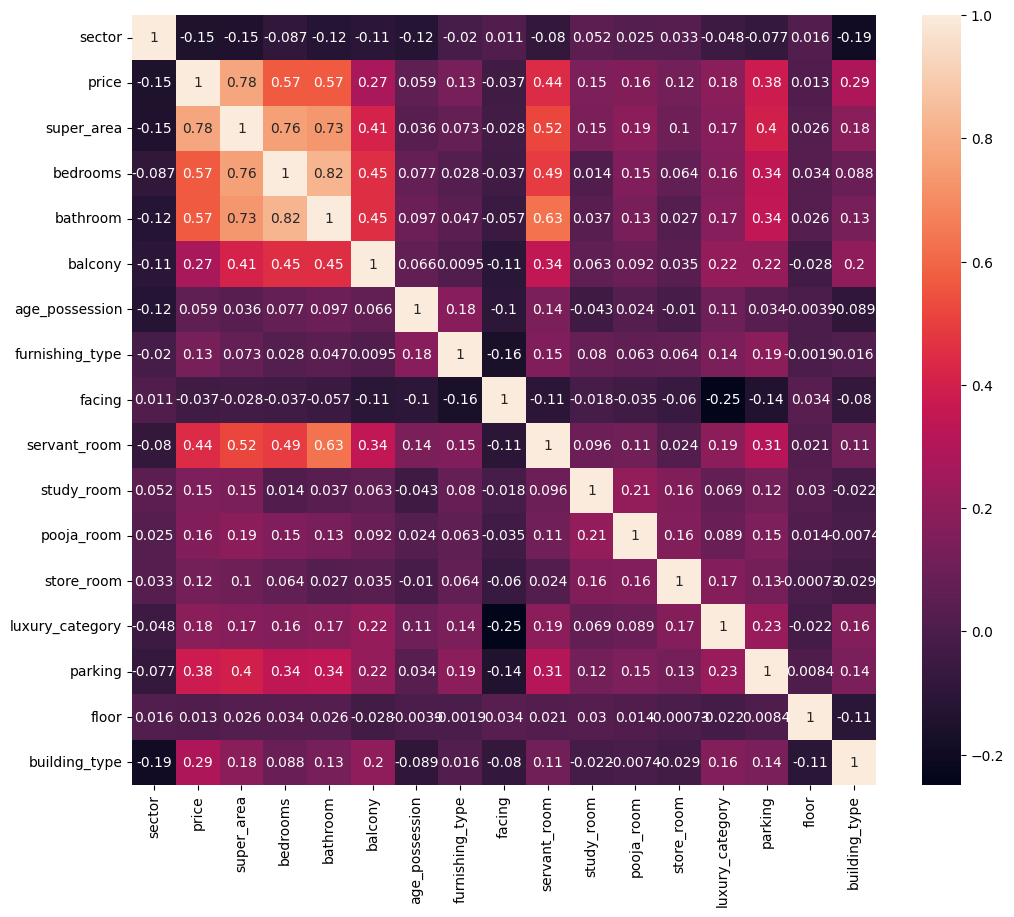

In [57]:
plt.figure(figsize= (12,10))
sns.heatmap(df.corr(),annot=True)

In [58]:
corr_fi = df.corr()['price'].sort_values(ascending=False).to_frame().iloc[1:].reset_index().rename(columns = {'index':'feature','price':'corr_coeff'})
corr_fi

,feature,corr_coeff
0,super_area,0.779894
1,bathroom,0.569996
2,bedrooms,0.567906
3,servant_room,0.440503
4,parking,0.377006
5,building_type,0.286044
6,balcony,0.270204
7,luxury_category,0.184557
8,pooja_room,0.159363
9,study_room,0.150453


### 1. Random Forest Feature importance

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X,Y)

#extracting feature importance
rf_fi = pd.DataFrame( {
    'feature': X.columns,
    'rf_importance' : rf.feature_importances_
}).sort_values( by = 'rf_importance', ascending = False)

rf_fi

,feature,rf_importance
1,super_area,0.680917
0,sector,0.202993
15,building_type,0.030166
5,age_possession,0.015942
3,bathroom,0.015868
7,facing,0.009151
2,bedrooms,0.006266
8,servant_room,0.006259
13,parking,0.006214
4,balcony,0.005302


### 2. Gradient boosting feature importance

In [60]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X,Y)

#extract feature importance
gb_fi = pd.DataFrame({
    'feature':X.columns,
    'gb_importance': gb.feature_importances_
}).sort_values('gb_importance', ascending=False)

gb_fi

,feature,gb_importance
1,super_area,0.707237
0,sector,0.217983
15,building_type,0.030499
3,bathroom,0.019940
13,parking,0.005237
8,servant_room,0.005226
10,pooja_room,0.003570
5,age_possession,0.003522
6,furnishing_type,0.001979
4,balcony,0.001472


### 3. Permutation Importance

In [61]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size=0.2 , random_state= 42)

#training random forest model on training data
rf = RandomForestRegressor(n_estimators=100)
rf.fit(x_train,y_train)

#calc permutation importance
perm_importance = permutation_importance(rf,x_test,y_test,n_repeats=30)

#visualize
pi_fi = pd.DataFrame({
    'feature':X.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values('permutation_importance',ascending=False)

pi_fi

,feature,permutation_importance
1,super_area,0.955061
0,sector,0.434938
15,building_type,0.073621
2,bedrooms,0.016199
3,bathroom,0.013379
5,age_possession,0.011256
4,balcony,0.002907
8,servant_room,0.002640
12,luxury_category,0.002215
13,parking,0.001952


### 4.Recursive Feature Elemination (RFE) 

In [62]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X.shape[1], step=1)
selector_label = selector_label.fit(X, Y)

# Get the selected features based on RFE
selected_features = X.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
rfe_fi = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

rfe_fi


,feature,rfe_score
1,super_area,0.679605
0,sector,0.203597
15,building_type,0.030084
5,age_possession,0.016584
3,bathroom,0.015071
7,facing,0.009092
13,parking,0.007074
8,servant_room,0.006432
2,bedrooms,0.006047
4,balcony,0.005319


In [63]:
final_fi_df = corr_fi.merge(rf_fi, on= 'feature').merge(gb_fi, on = 'feature').merge(pi_fi,on = 'feature').merge(rfe_fi, on= 'feature').set_index('feature')

In [64]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,rfe_score
feature,,,,,
super_area,0.779894,0.680917,0.707237,0.955061,0.679605
bathroom,0.569996,0.015868,0.019940,0.013379,0.015071
bedrooms,0.567906,0.006266,0.000196,0.016199,0.006047
servant_room,0.440503,0.006259,0.005226,0.002640,0.006432
parking,0.377006,0.006214,0.005237,0.001952,0.007074
building_type,0.286044,0.030166,0.030499,0.073621,0.030084
balcony,0.270204,0.005302,0.001472,0.002907,0.005319
luxury_category,0.184557,0.003684,0.001194,0.002215,0.003130
pooja_room,0.159363,0.003587,0.003570,0.000349,0.003552


In [65]:
ranked_df = final_fi_df.iloc[:,1:].rank(ascending=False, method = 'min')
ranked_df['average_rank'] = ranked_df.mean(axis=1)
ranked_df.sort_values('average_rank', ascending=True).reset_index()

,feature,rf_importance,gb_importance,permutation_importance,rfe_score,average_rank
0,super_area,1.0,1.0,1.0,1.0,1.00
1,sector,2.0,2.0,2.0,2.0,2.00
2,building_type,3.0,3.0,3.0,3.0,3.00
3,bathroom,5.0,4.0,5.0,5.0,4.75
4,age_possession,4.0,8.0,6.0,4.0,5.50
5,servant_room,8.0,6.0,8.0,8.0,7.50
6,parking,9.0,5.0,10.0,7.0,7.75
7,bedrooms,7.0,14.0,4.0,9.0,8.50
8,balcony,10.0,10.0,7.0,10.0,9.25
9,facing,6.0,12.0,16.0,6.0,10.00


In [66]:
['facing','floor','store_room','furnishing_type','study_room','pooja_room']

['facing',
 'floor',
 'store_room',
 'furnishing_type',
 'study_room',
 'pooja_room']

In [67]:
#normalise each value
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [68]:
final_fi_df.mean(axis=1).sort_values(ascending=False)

feature
super_area         0.579320
sector             0.174751
building_type      0.042458
bathroom           0.041030
bedrooms           0.033621
servant_room       0.026412
parking            0.023203
balcony            0.016592
age_possession     0.011691
luxury_category    0.011313
pooja_room         0.010321
study_room         0.009363
furnishing_type    0.008667
store_room         0.006854
floor              0.002642
facing             0.001763
dtype: float64

##### Observation
- Looking at this data, it seems that the columns ['facing','floor','store_room','furnishing_type','study_room','pooja_room'] have the least feature importances
- Need to investigate the impact of dropping these columns on the r2 score

### Making testing model

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
rf = RandomForestRegressor(n_estimators=100 , random_state=42)

scores = cross_val_score(estimator=rf, X=X, y= Y, cv=5 , scoring= 'r2')

In [70]:
X

,sector,super_area,bedrooms,bathroom,balcony,age_possession,furnishing_type,facing,servant_room,study_room,pooja_room,store_room,luxury_category,parking,floor,building_type
0,25.0,1278.0000,2,2,2.0,2.0,2.0,8.0,0,0,0,1,1.0,1,0.0,0.0
1,130.0,682.3526,2,2,2.0,2.0,2.0,0.0,0,0,0,0,1.0,2,1.0,1.0
2,94.0,1198.0000,2,2,2.0,4.0,1.0,1.0,0,0,0,0,2.0,1,0.0,1.0
3,104.0,3240.0000,4,4,2.0,1.0,3.0,2.0,1,0,1,0,1.0,2,2.0,0.0
4,130.0,1065.0000,2,2,2.0,1.0,2.0,8.0,0,0,0,0,0.0,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5587,130.0,1313.5000,4,4,2.0,3.0,2.0,1.0,0,0,0,0,1.0,2,2.0,1.0
5588,120.0,3500.0000,4,4,4.0,2.0,1.0,2.0,1,1,0,0,2.0,2,2.0,1.0
5589,116.0,1628.0000,3,4,4.0,2.0,2.0,5.0,1,0,0,0,1.0,1,1.0,1.0
5590,86.0,2916.6800,3,3,2.0,1.0,2.0,1.0,0,0,0,0,1.0,0,2.0,2.0


In [71]:
scores.mean()

0.8707892654983634

In [72]:
#checking after dropping less important columns ['facing','floor','store_room','furnishing_type','study_room']
X_temp = X.drop(columns = ['facing','floor','store_room','furnishing_type','study_room','pooja_room']) 

rf = RandomForestRegressor(n_estimators= 100 ,random_state=42)
scores = cross_val_score(estimator=rf, X=X_temp, y= Y, cv=5 , scoring= 'r2')

scores.mean()

0.8775457897176626

- The columns can be dropped

In [73]:
df_selected = df.drop(columns = ['facing','floor','store_room','furnishing_type','study_room','pooja_room'])

In [74]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5592 entries, 0 to 5591
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sector           5592 non-null   float64
 1   price            5592 non-null   float64
 2   super_area       5592 non-null   float64
 3   bedrooms         5592 non-null   int64  
 4   bathroom         5592 non-null   int64  
 5   balcony          5592 non-null   float64
 6   age_possession   5592 non-null   float64
 7   servant_room     5592 non-null   int64  
 8   luxury_category  5592 non-null   float64
 9   parking          5592 non-null   int64  
 10  building_type    5592 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 480.7 KB


### Building baseline model

In [75]:
df_selected

,sector,price,super_area,bedrooms,bathroom,balcony,age_possession,servant_room,luxury_category,parking,building_type
0,25.0,0.70,1278.0000,2,2,2.0,2.0,0,1.0,1,0.0
1,130.0,0.38,682.3526,2,2,2.0,2.0,0,1.0,2,1.0
2,94.0,1.35,1198.0000,2,2,2.0,4.0,0,2.0,1,1.0
3,104.0,3.40,3240.0000,4,4,2.0,1.0,1,1.0,2,0.0
4,130.0,0.95,1065.0000,2,2,2.0,1.0,0,0.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5587,130.0,0.88,1313.5000,4,4,2.0,3.0,0,1.0,2,1.0
5588,120.0,3.75,3500.0000,4,4,4.0,2.0,1,2.0,2,1.0
5589,116.0,1.45,1628.0000,3,4,4.0,2.0,1,1.0,1,1.0
5590,86.0,3.85,2916.6800,3,3,2.0,1.0,0,1.0,0,2.0


In [76]:
X = df_selected.drop(columns=['price'])
Y = df_selected['price']

In [77]:
Y_transformed = np.log1p(Y)

In [78]:
from sklearn.model_selection import KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),['super_area','bedrooms','bathroom','servant_room','parking']),
        ('onehot', OneHotEncoder(handle_unknown = 'infrequent_if_exist'),['sector'])
    ],
    remainder='passthrough'
)

In [80]:
#creating pipeline
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('regressor', SVR(kernel='rbf')) 
])

In [81]:
#k fold cross validation
kfold = KFold(n_splits=10,shuffle=True, random_state=42)
scores = cross_val_score(pipeline,X,Y_transformed,cv = kfold , scoring='r2')


In [82]:
scores.mean()

0.9210717965342141

In [83]:
x_train,x_test, y_train, y_test = train_test_split(X,Y_transformed, test_size=0.2)

In [84]:
pipeline.fit(x_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', StandardScaler(),
                                                  ['super_area', 'bedrooms',
                                                   'bathroom', 'servant_room',
                                                   'parking']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['sector'])])),
                ('regressor', SVR())])

In [85]:
y_pred = pipeline.predict(x_test)
y_pred = np.expm1(y_pred)

In [86]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(np.expm1(y_test),y_pred)

0.37585112628481004

### 
- Based on the above tests -> columns can be dropped

In [87]:
df_selected.columns

Index(['sector', 'price', 'super_area', 'bedrooms', 'bathroom', 'balcony',
       'age_possession', 'servant_room', 'luxury_category', 'parking',
       'building_type'],
      dtype='object')

In [88]:
df_non_feature_selected[['sector', 'price', 'super_area', 'bedrooms', 'bathroom', 'balcony',
       'age_possession', 'servant_room', 'luxury_category', 'parking',
       'building_type']].to_csv('4.6_dataset_feature_selected.csv', index= False)